<a href="https://colab.research.google.com/github/dhanwariagarvit21/information-diffusion-/blob/main/toy_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!pip install pyarrow


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt



In [32]:
index_sp500 = pd.read_parquet('/content/download/index_SPX500_USD_30s.parquet')
AAPl = pd.read_parquet('/content/download/stocks_AAPL_30s.parquet')
MSFT = pd.read_parquet('/content/download/stocks_MSFT_30s.parquet')
NVDA = pd.read_parquet('/content/download/stocks_NVDA_30s.parquet')
TSLA = pd.read_parquet('/content/download/stocks_TSLA_30s.parquet')
JNJ = pd.read_parquet('/content/download/stocks_JNJ_30s.parquet')
JPM = pd.read_parquet('/content/download/stocks_JPM_30s.parquet')
WMT = pd.read_parquet('/content/download/stocks_WMT_30s.parquet')
XOM = pd.read_parquet('/content/download/stocks_XOM_30s.parquet')
events = pd.read_csv('/content/download/information_diffusion_US8_core_events_2025-09-01_to_2026-09-01_UK_time.csv')




In [33]:
index_sp500

,ts,symbol,open,high,low,close,volume
0,2025-09-02 13:30:00+00:00,SPX500/USD,6401.51,6401.51,6374.71,6374.71,0.0
1,2025-09-02 13:30:30+00:00,SPX500/USD,6374.84,6377.77,6373.50,6373.81,0.0
2,2025-09-02 13:31:00+00:00,SPX500/USD,6373.45,6374.09,6372.00,6372.52,0.0
3,2025-09-02 13:31:30+00:00,SPX500/USD,6371.81,6372.62,6369.57,6371.70,0.0
4,2025-09-02 13:32:00+00:00,SPX500/USD,6371.18,6373.73,6369.85,6371.67,0.0
...,...,...,...,...,...,...,...
348745,2026-09-01 23:57:30+00:00,SPX500/USD,7639.10,7639.30,7639.00,7639.00,9.0
348746,2026-09-01 23:58:00+00:00,SPX500/USD,7639.30,7639.30,7639.00,7639.00,2.0
348747,2026-09-01 23:58:30+00:00,SPX500/USD,7639.10,7639.30,7638.80,7639.30,13.0
348748,2026-09-01 23:59:00+00:00,SPX500/USD,7639.10,7639.50,7639.10,7639.50,17.0


In [34]:
AAPl

,ts,symbol,open,high,low,close,volume
0,2025-09-02 08:00:00+00:00,AAPL,231.89,231.89,230.62,231.11,2610.0
1,2025-09-02 08:00:30+00:00,AAPL,230.90,231.06,230.76,230.90,675.0
2,2025-09-02 08:01:00+00:00,AAPL,230.92,231.00,230.57,230.90,2822.0
3,2025-09-02 08:01:30+00:00,AAPL,230.69,230.88,230.69,230.86,1343.0
4,2025-09-02 08:02:00+00:00,AAPL,230.86,230.87,230.70,230.84,232.0
...,...,...,...,...,...,...,...
430460,2026-09-01 23:57:30+00:00,AAPL,325.13,325.13,325.13,325.13,10.0
430461,2026-09-01 23:58:00+00:00,AAPL,325.13,325.14,325.12,325.12,1016.0
430462,2026-09-01 23:58:30+00:00,AAPL,325.13,325.13,325.13,325.13,2.0
430463,2026-09-01 23:59:00+00:00,AAPL,325.12,325.12,325.11,325.12,303.0


In [35]:
NVDA

,ts,symbol,open,high,low,close,volume
0,2025-09-02 08:00:00+00:00,NVDA,172.35,173.60,172.20,172.44,42813.0
1,2025-09-02 08:00:30+00:00,NVDA,172.44,172.88,172.30,172.68,20752.0
2,2025-09-02 08:01:00+00:00,NVDA,172.77,172.78,172.44,172.47,22024.0
3,2025-09-02 08:01:30+00:00,NVDA,172.47,172.53,172.34,172.36,19936.0
4,2025-09-02 08:02:00+00:00,NVDA,172.35,172.40,172.29,172.35,25350.0
...,...,...,...,...,...,...,...
471192,2026-09-01 23:57:30+00:00,NVDA,217.54,217.55,217.49,217.53,1591.0
471193,2026-09-01 23:58:00+00:00,NVDA,217.52,217.53,217.50,217.50,473.0
471194,2026-09-01 23:58:30+00:00,NVDA,217.50,217.50,217.49,217.49,151.0
471195,2026-09-01 23:59:00+00:00,NVDA,217.49,217.50,217.48,217.50,791.0


In [36]:
TSLA

,ts,symbol,open,high,low,close,volume
0,2025-09-02 08:00:00+00:00,TSLA,332.00,333.90,331.50,332.82,29034.0
1,2025-09-02 08:00:30+00:00,TSLA,333.27,333.35,332.11,332.48,3588.0
2,2025-09-02 08:01:00+00:00,TSLA,332.56,332.56,331.67,331.96,6697.0
3,2025-09-02 08:01:30+00:00,TSLA,331.73,332.39,331.73,332.35,3178.0
4,2025-09-02 08:02:00+00:00,TSLA,332.30,332.50,332.03,332.26,6089.0
...,...,...,...,...,...,...,...
465708,2026-09-01 23:57:30+00:00,TSLA,355.84,355.87,355.82,355.87,193.0
465709,2026-09-01 23:58:00+00:00,TSLA,355.90,355.90,355.87,355.88,76.0
465710,2026-09-01 23:58:30+00:00,TSLA,355.89,355.90,355.88,355.90,221.0
465711,2026-09-01 23:59:00+00:00,TSLA,355.90,355.91,355.90,355.91,993.0


In [37]:
MSFT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437774 entries, 0 to 437773
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype              
---  ------  --------------   -----              
 0   ts      437774 non-null  datetime64[us, UTC]
 1   symbol  437774 non-null  object             
 2   open    437774 non-null  float64            
 3   high    437774 non-null  float64            
 4   low     437774 non-null  float64            
 5   close   437774 non-null  float64            
 6   volume  437774 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(5), object(1)
memory usage: 23.4+ MB


In [65]:
Market_hours = ["13:30:00","20:00:00"]
datetime_array = pd.to_datetime(Market_hours, format="%H:%M:%S")
premarket_hours = ["08:00:00","13:29:59"]
premarket_datetime_array = pd.to_datetime(premarket_hours, format="%H:%M:%S")

In [39]:
events

,event_id,date,time_et,datetime_utc,datetime_uk,time_uk,datetime_et_original,datetime_et,ticker,company,...,notes,benchmark,market,timezone_basis,event_window_start,event_window_end,abnormal_return,cumulative_abnormal_return,price_data_source,timestamp_quality
0,1,2025-09-17,14:00,2025-09-17 18:00:00,2025-09-17 19:00:00 BST,19:00:00,2025-09-17 14:00:00 EDT,2025-09-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,Target-rate midpoint after decision: 4.125% ; ...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
1,2,2025-10-14,06:38,2025-10-14 10:38:00,2025-10-14 11:38:00 BST,11:38:00,2025-10-14 06:38:00 EDT,2025-10-14 06:38:00 EDT,JPM,JPMorgan Chase & Co.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
2,3,2025-10-14,06:40,2025-10-14 10:40:00,2025-10-14 11:40:00 BST,11:40:00,2025-10-14 06:40:00 EDT,2025-10-14 06:40:00 EDT,JNJ,Johnson & Johnson,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
3,4,2025-10-22,16:05,2025-10-22 20:05:00,2025-10-22 21:05:00 BST,21:05:00,2025-10-22 16:05:00 EDT,2025-10-22 16:05:00 EDT,TSLA,Tesla Inc.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
4,5,2025-10-29,14:00,2025-10-29 18:00:00,2025-10-29 18:00:00 GMT,18:00:00,2025-10-29 14:00:00 EDT,2025-10-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,Target-rate midpoint after decision: 3.875% ; ...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
5,6,2025-10-29,16:05,2025-10-29 20:05:00,2025-10-29 20:05:00 GMT,20:05:00,2025-10-29 16:05:00 EDT,2025-10-29 16:05:00 EDT,MSFT,Microsoft Corp.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
6,7,2025-10-30,16:32,2025-10-30 20:32:00,2025-10-30 20:32:00 GMT,20:32:00,2025-10-30 16:32:00 EDT,2025-10-30 16:32:00 EDT,AAPL,Apple Inc.,...,Release timestamp from TheStockCatalyst; estim...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
7,8,2025-10-31,06:31,2025-10-31 10:31:00,2025-10-31 10:31:00 GMT,10:31:00,2025-10-31 06:31:00 EDT,2025-10-31 06:31:00 EDT,XOM,Exxon Mobil Corp.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
8,9,2025-11-19,16:21,2025-11-19 21:21:00,2025-11-19 21:21:00 GMT,21:21:00,2025-11-19 16:21:00 EST,2025-11-19 16:21:00 EST,NVDA,NVIDIA Corp.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
9,10,2025-11-20,07:00,2025-11-20 12:00:00,2025-11-20 12:00:00 GMT,12:00:00,2025-11-20 07:00:00 EST,2025-11-20 07:00:00 EST,WMT,Walmart Inc.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp


In [66]:
def trim_database(df,datetime_array):
  start_time = datetime_array[0].time()
  end_time = datetime_array[1].time()
  filtered_df = df[df['ts'].dt.time >= start_time]
  filtered_df = filtered_df[filtered_df['ts'].dt.time <= end_time]
  return filtered_df

In [70]:
MSFT = trim_database(MSFT,datetime_array)
AAPl = trim_database(AAPl,datetime_array)
NVDA = trim_database(NVDA,datetime_array)
TSLA = trim_database(TSLA,datetime_array)
JNJ = trim_database(JNJ,datetime_array)
JPM = trim_database(JPM,datetime_array)
WMT = trim_database(WMT,datetime_array)
XOM = trim_database(XOM,datetime_array)
index_sp500 = trim_database(index_sp500,datetime_array)

In [69]:
MSFT_premarket = trim_database(MSFT,premarket_datetime_array)
AAPl_premarket = trim_database(AAPl,premarket_datetime_array)
NVDA_premarket = trim_database(NVDA,premarket_datetime_array)
TSLA_premarket = trim_database(TSLA,premarket_datetime_array)
JNJ_premarket = trim_database(JNJ,premarket_datetime_array)
JPM_premarket = trim_database(JPM,premarket_datetime_array)
WMT_premarket = trim_database(WMT,premarket_datetime_array)
XOM_premarket = trim_database(XOM,premarket_datetime_array)
index_sp500_premarket = trim_database(index_sp500,premarket_datetime_array)

In [42]:

def prepare_df_for_merge(df):
    symbol = df['symbol'].iloc[0]
    df = df.set_index('ts')
    df = df.drop(columns=['symbol'])
    df.columns = [f'{symbol}_{col}' for col in df.columns]
    return df
index_sp500_prepared = prepare_df_for_merge(index_sp500)
aapl_prepared = prepare_df_for_merge(AAPl)
msft_prepared = prepare_df_for_merge(MSFT)
nvda_prepared = prepare_df_for_merge(NVDA)
tsla_prepared = prepare_df_for_merge(TSLA)
jnj_prepared = prepare_df_for_merge(JNJ)
jpm_prepared = prepare_df_for_merge(JPM)
wmt_prepared = prepare_df_for_merge(WMT)
xom_prepared = prepare_df_for_merge(XOM)

In [43]:
merged_side_by_side_df = index_sp500_prepared
merged_side_by_side_df = pd.merge(merged_side_by_side_df, aapl_prepared, left_index=True, right_index=True, how='outer')
merged_side_by_side_df = pd.merge(merged_side_by_side_df, msft_prepared, left_index=True, right_index=True, how='outer')
merged_side_by_side_df = pd.merge(merged_side_by_side_df, nvda_prepared, left_index=True, right_index=True, how='outer')
merged_side_by_side_df = pd.merge(merged_side_by_side_df, tsla_prepared, left_index=True, right_index=True, how='outer')
merged_side_by_side_df = pd.merge(merged_side_by_side_df, jnj_prepared, left_index=True, right_index=True, how='outer')
merged_side_by_side_df = pd.merge(merged_side_by_side_df, jpm_prepared, left_index=True, right_index=True, how='outer')
merged_side_by_side_df = pd.merge(merged_side_by_side_df, wmt_prepared, left_index=True, right_index=True, how='outer')
merged_side_by_side_df = pd.merge(merged_side_by_side_df, xom_prepared, left_index=True, right_index=True, how='outer')
display(merged_side_by_side_df.head())
display(merged_side_by_side_df.info())

,SPX500/USD_open,SPX500/USD_high,SPX500/USD_low,SPX500/USD_close,SPX500/USD_volume,AAPL_open,AAPL_high,AAPL_low,AAPL_close,AAPL_volume,...,WMT_open,WMT_high,WMT_low,WMT_close,WMT_volume,XOM_open,XOM_high,XOM_low,XOM_close,XOM_volume
ts,,,,,,,,,,,,,,,,,,,,,
2025-09-02 13:30:00+00:00,6401.51,6401.51,6374.71,6374.71,0.0,229.43,229.70,229.05,229.23,1534749.0,...,97.18,97.71,97.00,97.35,993855.0,114.12,114.38,114.00,114.33,8824.0
2025-09-02 13:30:30+00:00,6374.84,6377.77,6373.50,6373.81,0.0,229.19,229.22,228.55,228.60,141878.0,...,97.35,97.37,97.11,97.13,81845.0,114.25,114.38,114.21,114.25,1844.0
2025-09-02 13:31:00+00:00,6373.45,6374.09,6372.00,6372.52,0.0,228.64,228.79,228.24,228.41,122604.0,...,97.16,97.25,97.11,97.17,52742.0,114.33,114.55,114.25,114.46,10723.0
2025-09-02 13:31:30+00:00,6371.81,6372.62,6369.57,6371.70,0.0,228.41,228.66,227.90,228.24,111813.0,...,97.18,97.31,97.14,97.28,28794.0,114.47,114.60,114.30,114.44,4333.0
2025-09-02 13:32:00+00:00,6371.18,6373.73,6369.85,6371.67,0.0,228.22,228.27,227.67,227.91,126118.0,...,97.30,97.44,97.23,97.40,46662.0,114.45,114.60,114.31,114.58,4201.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 195742 entries, 2025-09-02 13:30:00+00:00 to 2026-09-01 20:00:00+00:00
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SPX500/USD_open    182874 non-null  float64
 1   SPX500/USD_high    182874 non-null  float64
 2   SPX500/USD_low     182874 non-null  float64
 3   SPX500/USD_close   182874 non-null  float64
 4   SPX500/USD_volume  182874 non-null  float64
 5   AAPL_open          192584 non-null  float64
 6   AAPL_high          192584 non-null  float64
 7   AAPL_low           192584 non-null  float64
 8   AAPL_close         192584 non-null  float64
 9   AAPL_volume        192584 non-null  float64
 10  MSFT_open          189670 non-null  float64
 11  MSFT_high          189670 non-null  float64
 12  MSFT_low           189670 non-null  float64
 13  MSFT_close         189670 non-null  float64
 14  MSFT_volume        189670 non-null  float64
 15  NVDA_

None

In [44]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   event_id                    40 non-null     int64  
 1   date                        40 non-null     object 
 2   time_et                     40 non-null     object 
 3   datetime_utc                40 non-null     object 
 4   datetime_uk                 40 non-null     object 
 5   time_uk                     40 non-null     object 
 6   datetime_et_original        40 non-null     object 
 7   datetime_et                 40 non-null     object 
 8   ticker                      40 non-null     object 
 9   company                     40 non-null     object 
 10  event_type                  40 non-null     object 
 11  release_session             40 non-null     object 
 12  eps_estimate                32 non-null     float64
 13  eps_actual                  32 non-nu

In [45]:
events

,event_id,date,time_et,datetime_utc,datetime_uk,time_uk,datetime_et_original,datetime_et,ticker,company,...,notes,benchmark,market,timezone_basis,event_window_start,event_window_end,abnormal_return,cumulative_abnormal_return,price_data_source,timestamp_quality
0,1,2025-09-17,14:00,2025-09-17 18:00:00,2025-09-17 19:00:00 BST,19:00:00,2025-09-17 14:00:00 EDT,2025-09-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,Target-rate midpoint after decision: 4.125% ; ...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
1,2,2025-10-14,06:38,2025-10-14 10:38:00,2025-10-14 11:38:00 BST,11:38:00,2025-10-14 06:38:00 EDT,2025-10-14 06:38:00 EDT,JPM,JPMorgan Chase & Co.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
2,3,2025-10-14,06:40,2025-10-14 10:40:00,2025-10-14 11:40:00 BST,11:40:00,2025-10-14 06:40:00 EDT,2025-10-14 06:40:00 EDT,JNJ,Johnson & Johnson,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
3,4,2025-10-22,16:05,2025-10-22 20:05:00,2025-10-22 21:05:00 BST,21:05:00,2025-10-22 16:05:00 EDT,2025-10-22 16:05:00 EDT,TSLA,Tesla Inc.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
4,5,2025-10-29,14:00,2025-10-29 18:00:00,2025-10-29 18:00:00 GMT,18:00:00,2025-10-29 14:00:00 EDT,2025-10-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,Target-rate midpoint after decision: 3.875% ; ...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
5,6,2025-10-29,16:05,2025-10-29 20:05:00,2025-10-29 20:05:00 GMT,20:05:00,2025-10-29 16:05:00 EDT,2025-10-29 16:05:00 EDT,MSFT,Microsoft Corp.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
6,7,2025-10-30,16:32,2025-10-30 20:32:00,2025-10-30 20:32:00 GMT,20:32:00,2025-10-30 16:32:00 EDT,2025-10-30 16:32:00 EDT,AAPL,Apple Inc.,...,Release timestamp from TheStockCatalyst; estim...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
7,8,2025-10-31,06:31,2025-10-31 10:31:00,2025-10-31 10:31:00 GMT,10:31:00,2025-10-31 06:31:00 EDT,2025-10-31 06:31:00 EDT,XOM,Exxon Mobil Corp.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
8,9,2025-11-19,16:21,2025-11-19 21:21:00,2025-11-19 21:21:00 GMT,21:21:00,2025-11-19 16:21:00 EST,2025-11-19 16:21:00 EST,NVDA,NVIDIA Corp.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp
9,10,2025-11-20,07:00,2025-11-20 12:00:00,2025-11-20 12:00:00 GMT,12:00:00,2025-11-20 07:00:00 EST,2025-11-20 07:00:00 EST,WMT,Walmart Inc.,...,NaN,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp


In [46]:
events['time_uk'] = pd.to_datetime(events['time_uk'], format='%H:%M:%S').dt.time
events['datetime_uk'] = pd.to_datetime(events['datetime_uk'], format='mixed', utc=True)
events['datetime_utc'] = pd.to_datetime(events['datetime_utc'], utc=True)
events['datetime_us'] = events['datetime_utc'].dt.tz_convert('America/New_York')

events

/tmp/ipykernel_6871/1225574574.py:2: FutureWarning: Parsed string "2025-09-17 19:00:00 BST" included an un-recognized timezone "BST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  events['datetime_uk'] = pd.to_datetime(events['datetime_uk'], format='mixed', utc=True)
/tmp/ipykernel_6871/1225574574.py:2: FutureWarning: Parsed string "2025-10-14 11:38:00 BST" included an un-recognized timezone "BST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  events['datetime_uk'] = pd.to_datetime(events['datetime_uk'], format='mixed', utc=True)
/tmp/ipykernel_6871/1225574574.py:2: FutureWarning: Parsed string "2025-10-14 11:40:00 BST" included an un-recognized timezone "BST". Dropping unrecognized timezones is depre

,event_id,date,time_et,datetime_utc,datetime_uk,time_uk,datetime_et_original,datetime_et,ticker,company,...,benchmark,market,timezone_basis,event_window_start,event_window_end,abnormal_return,cumulative_abnormal_return,price_data_source,timestamp_quality,datetime_us
0,1,2025-09-17,14:00,2025-09-17 18:00:00+00:00,2025-09-17 19:00:00+00:00,19:00:00,2025-09-17 14:00:00 EDT,2025-09-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00
1,2,2025-10-14,06:38,2025-10-14 10:38:00+00:00,2025-10-14 11:38:00+00:00,11:38:00,2025-10-14 06:38:00 EDT,2025-10-14 06:38:00 EDT,JPM,JPMorgan Chase & Co.,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-14 06:38:00-04:00
2,3,2025-10-14,06:40,2025-10-14 10:40:00+00:00,2025-10-14 11:40:00+00:00,11:40:00,2025-10-14 06:40:00 EDT,2025-10-14 06:40:00 EDT,JNJ,Johnson & Johnson,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-14 06:40:00-04:00
3,4,2025-10-22,16:05,2025-10-22 20:05:00+00:00,2025-10-22 21:05:00+00:00,21:05:00,2025-10-22 16:05:00 EDT,2025-10-22 16:05:00 EDT,TSLA,Tesla Inc.,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-22 16:05:00-04:00
4,5,2025-10-29,14:00,2025-10-29 18:00:00+00:00,2025-10-29 18:00:00+00:00,18:00:00,2025-10-29 14:00:00 EDT,2025-10-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-29 14:00:00-04:00
5,6,2025-10-29,16:05,2025-10-29 20:05:00+00:00,2025-10-29 20:05:00+00:00,20:05:00,2025-10-29 16:05:00 EDT,2025-10-29 16:05:00 EDT,MSFT,Microsoft Corp.,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-29 16:05:00-04:00
6,7,2025-10-30,16:32,2025-10-30 20:32:00+00:00,2025-10-30 20:32:00+00:00,20:32:00,2025-10-30 16:32:00 EDT,2025-10-30 16:32:00 EDT,AAPL,Apple Inc.,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-30 16:32:00-04:00
7,8,2025-10-31,06:31,2025-10-31 10:31:00+00:00,2025-10-31 10:31:00+00:00,10:31:00,2025-10-31 06:31:00 EDT,2025-10-31 06:31:00 EDT,XOM,Exxon Mobil Corp.,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-31 06:31:00-04:00
8,9,2025-11-19,16:21,2025-11-19 21:21:00+00:00,2025-11-19 21:21:00+00:00,21:21:00,2025-11-19 16:21:00 EST,2025-11-19 16:21:00 EST,NVDA,NVIDIA Corp.,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-11-19 16:21:00-05:00
9,10,2025-11-20,07:00,2025-11-20 12:00:00+00:00,2025-11-20 12:00:00+00:00,12:00:00,2025-11-20 07:00:00 EST,2025-11-20 07:00:00 EST,WMT,Walmart Inc.,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-11-20 07:00:00-05:00


In [47]:
market_start = datetime_array[0].time()
market_end = datetime_array[1].time()
events['time_uk'] = pd.to_datetime(events['time_uk'], format='%H:%M:%S').dt.time
events_trimmed = events[events['time_uk'] >= market_start]
events_trimmed = events_trimmed[events_trimmed['time_uk'] <= market_end]

In [48]:
events_trimmed

,event_id,date,time_et,datetime_utc,datetime_uk,time_uk,datetime_et_original,datetime_et,ticker,company,...,benchmark,market,timezone_basis,event_window_start,event_window_end,abnormal_return,cumulative_abnormal_return,price_data_source,timestamp_quality,datetime_us
0,1,2025-09-17,14:00,2025-09-17 18:00:00+00:00,2025-09-17 19:00:00+00:00,19:00:00,2025-09-17 14:00:00 EDT,2025-09-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00
4,5,2025-10-29,14:00,2025-10-29 18:00:00+00:00,2025-10-29 18:00:00+00:00,18:00:00,2025-10-29 14:00:00 EDT,2025-10-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-10-29 14:00:00-04:00
10,11,2025-12-10,14:00,2025-12-10 19:00:00+00:00,2025-12-10 19:00:00+00:00,19:00:00,2025-12-10 14:00:00 EST,2025-12-10 14:00:00 EST,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-12-10 14:00:00-05:00
13,14,2026-01-28,14:00,2026-01-28 19:00:00+00:00,2026-01-28 19:00:00+00:00,19:00:00,2026-01-28 14:00:00 EST,2026-01-28 14:00:00 EST,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-01-28 14:00:00-05:00
20,21,2026-03-18,14:00,2026-03-18 18:00:00+00:00,2026-03-18 18:00:00+00:00,18:00:00,2026-03-18 14:00:00 EDT,2026-03-18 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-03-18 14:00:00-04:00
24,25,2026-04-29,14:00,2026-04-29 18:00:00+00:00,2026-04-29 19:00:00+00:00,19:00:00,2026-04-29 14:00:00 EDT,2026-04-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-04-29 14:00:00-04:00
30,31,2026-06-17,14:00,2026-06-17 18:00:00+00:00,2026-06-17 19:00:00+00:00,19:00:00,2026-06-17 14:00:00 EDT,2026-06-17 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-06-17 14:00:00-04:00
34,35,2026-07-29,14:00,2026-07-29 18:00:00+00:00,2026-07-29 19:00:00+00:00,19:00:00,2026-07-29 14:00:00 EDT,2026-07-29 14:00:00 EDT,ALL,Federal Reserve / FOMC,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-07-29 14:00:00-04:00


In [49]:
merged_side_by_side_df

,SPX500/USD_open,SPX500/USD_high,SPX500/USD_low,SPX500/USD_close,SPX500/USD_volume,AAPL_open,AAPL_high,AAPL_low,AAPL_close,AAPL_volume,...,WMT_open,WMT_high,WMT_low,WMT_close,WMT_volume,XOM_open,XOM_high,XOM_low,XOM_close,XOM_volume
ts,,,,,,,,,,,,,,,,,,,,,
2025-09-02 13:30:00+00:00,6401.51,6401.51,6374.71,6374.71,0.0,229.43,229.70,229.05,229.23,1534749.0,...,97.18,97.71,97.00,97.35,993855.0,114.12,114.38,114.00,114.33,8824.0
2025-09-02 13:30:30+00:00,6374.84,6377.77,6373.50,6373.81,0.0,229.19,229.22,228.55,228.60,141878.0,...,97.35,97.37,97.11,97.13,81845.0,114.25,114.38,114.21,114.25,1844.0
2025-09-02 13:31:00+00:00,6373.45,6374.09,6372.00,6372.52,0.0,228.64,228.79,228.24,228.41,122604.0,...,97.16,97.25,97.11,97.17,52742.0,114.33,114.55,114.25,114.46,10723.0
2025-09-02 13:31:30+00:00,6371.81,6372.62,6369.57,6371.70,0.0,228.41,228.66,227.90,228.24,111813.0,...,97.18,97.31,97.14,97.28,28794.0,114.47,114.60,114.30,114.44,4333.0
2025-09-02 13:32:00+00:00,6371.18,6373.73,6369.85,6371.67,0.0,228.22,228.27,227.67,227.91,126118.0,...,97.30,97.44,97.23,97.40,46662.0,114.45,114.60,114.31,114.58,4201.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-01 19:58:00+00:00,7628.20,7628.90,7627.70,7628.70,28.0,324.77,324.89,324.61,324.85,182927.0,...,105.88,105.90,105.86,105.89,104028.0,164.48,164.57,164.45,164.55,42720.0
2026-09-01 19:58:30+00:00,7629.20,7632.70,7628.90,7632.40,32.0,324.84,325.08,324.80,325.03,152908.0,...,105.89,105.93,105.89,105.91,83740.0,164.55,164.58,164.51,164.57,39800.0
2026-09-01 19:59:00+00:00,7631.90,7633.90,7630.40,7633.20,58.0,325.02,325.14,324.85,325.02,187665.0,...,105.91,105.93,105.86,105.91,103402.0,164.59,164.59,164.42,164.43,53496.0


In [50]:
merged_side_by_side_df['ts'] = pd.to_datetime(merged_side_by_side_df.index)
merged_side_by_side_df['date'] = merged_side_by_side_df['ts'].dt.date
events_trimmed['date'] = pd.to_datetime(events_trimmed['date']).dt.date
merged_df = pd.merge(merged_side_by_side_df, events_trimmed, left_on='date', right_on='date', how='inner')

In [51]:
merged_df

,SPX500/USD_open,SPX500/USD_high,SPX500/USD_low,SPX500/USD_close,SPX500/USD_volume,AAPL_open,AAPL_high,AAPL_low,AAPL_close,AAPL_volume,...,benchmark,market,timezone_basis,event_window_start,event_window_end,abnormal_return,cumulative_abnormal_return,price_data_source,timestamp_quality,datetime_us
0,6604.86,6610.82,6604.86,6609.32,0.0,238.96,239.73,238.79,239.60,920109.0,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00
1,6609.69,6611.59,6609.52,6611.59,0.0,239.60,240.10,239.60,239.96,342624.0,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00
2,6611.36,6612.28,6610.16,6610.16,0.0,239.92,239.94,239.39,239.62,87325.0,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00
3,6611.24,6611.28,6607.43,6609.66,0.0,239.62,239.90,239.22,239.39,89366.0,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00
4,6609.06,6611.16,6609.06,6609.86,0.0,239.37,239.68,239.29,239.47,56441.0,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2025-09-17 14:00:00-04:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6242,7327.10,7327.80,7325.80,7326.30,18.0,338.02,338.06,337.54,337.84,139789.0,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-07-29 14:00:00-04:00
6243,7325.80,7328.60,7325.80,7326.10,28.0,337.75,337.84,337.52,337.55,95343.0,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-07-29 14:00:00-04:00
6244,7324.10,7324.10,7321.80,7323.60,38.0,337.38,337.82,337.37,337.78,110857.0,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-07-29 14:00:00-04:00
6245,7323.10,7331.30,7323.10,7328.80,40.0,337.68,338.38,337.64,338.05,99269.0,...,^GSPC,US,Europe/London (GMT/BST),NaN,NaN,NaN,NaN,To be populated from 1-min/5-min OHLC data,Official/public release timestamp,2026-07-29 14:00:00-04:00


In [52]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6247 entries, 0 to 6246
Data columns (total 77 columns):
 #   Column                      Non-Null Count  Dtype                           
---  ------                      --------------  -----                           
 0   SPX500/USD_open             5852 non-null   float64                         
 1   SPX500/USD_high             5852 non-null   float64                         
 2   SPX500/USD_low              5852 non-null   float64                         
 3   SPX500/USD_close            5852 non-null   float64                         
 4   SPX500/USD_volume           5852 non-null   float64                         
 5   AAPL_open                   5441 non-null   float64                         
 6   AAPL_high                   5441 non-null   float64                         
 7   AAPL_low                    5441 non-null   float64                         
 8   AAPL_close                  5441 non-null   float64                 

In [53]:
cleaned_data = merged_df[['date','ts','time_et','SPX500/USD_close','SPX500/USD_volume','AAPL_close','AAPL_volume','MSFT_close','MSFT_volume','NVDA_close','NVDA_volume','TSLA_close','TSLA_volume','JNJ_close','JNJ_volume','JPM_close','JPM_volume','WMT_close','WMT_volume','XOM_close','XOM_volume','event_id']].copy()

In [54]:
cleaned_data['time_et'] = pd.to_datetime

In [55]:
cleaned_data

,date,ts,time_et,SPX500/USD_close,SPX500/USD_volume,AAPL_close,AAPL_volume,MSFT_close,MSFT_volume,NVDA_close,...,TSLA_volume,JNJ_close,JNJ_volume,JPM_close,JPM_volume,WMT_close,WMT_volume,XOM_close,XOM_volume,event_id
0,2025-09-17,2025-09-17 13:30:00+00:00,<function to_datetime at 0x7dbf298ae020>,6609.32,0.0,239.60,920109.0,510.50,462515.0,172.88,...,1013977.0,176.69,127631.0,310.26,180312.0,104.32,561984.0,114.17,3092.0,1
1,2025-09-17,2025-09-17 13:30:30+00:00,<function to_datetime at 0x7dbf298ae020>,6611.59,0.0,239.96,342624.0,510.25,16811.0,172.75,...,85438.0,177.03,12980.0,310.19,18817.0,104.56,65470.0,114.54,2349.0,1
2,2025-09-17,2025-09-17 13:31:00+00:00,<function to_datetime at 0x7dbf298ae020>,6610.16,0.0,239.62,87325.0,510.61,15591.0,172.74,...,112034.0,177.01,4272.0,310.41,8349.0,104.50,39510.0,114.38,3517.0,1
3,2025-09-17,2025-09-17 13:31:30+00:00,<function to_datetime at 0x7dbf298ae020>,6609.66,0.0,239.39,89366.0,510.18,31418.0,172.87,...,252544.0,177.45,2163.0,309.79,15866.0,104.55,31036.0,114.36,2495.0,1
4,2025-09-17,2025-09-17 13:32:00+00:00,<function to_datetime at 0x7dbf298ae020>,6609.86,0.0,239.47,56441.0,510.02,16518.0,172.74,...,84294.0,177.17,1598.0,309.61,3612.0,104.28,21271.0,114.48,4595.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6242,2026-07-29,2026-07-29 19:58:00+00:00,<function to_datetime at 0x7dbf298ae020>,7326.30,18.0,337.84,139789.0,390.05,82188.0,190.18,...,36610.0,265.83,11300.0,345.61,12829.0,114.30,33668.0,157.09,13523.0,35
6243,2026-07-29,2026-07-29 19:58:30+00:00,<function to_datetime at 0x7dbf298ae020>,7326.10,28.0,337.55,95343.0,389.69,77188.0,190.30,...,26181.0,265.72,14776.0,345.51,11524.0,114.27,43841.0,156.96,23867.0,35
6244,2026-07-29,2026-07-29 19:59:00+00:00,<function to_datetime at 0x7dbf298ae020>,7323.60,38.0,337.78,110857.0,390.23,73761.0,190.19,...,46994.0,265.62,11522.0,345.34,14341.0,114.15,47354.0,156.91,13143.0,35
6245,2026-07-29,2026-07-29 19:59:30+00:00,<function to_datetime at 0x7dbf298ae020>,7328.80,40.0,338.05,99269.0,390.89,72287.0,190.23,...,31097.0,265.65,11320.0,344.97,9636.0,114.25,55472.0,156.89,17222.0,35


In [56]:
cleaned_data['time_et'] = merged_df['time_et']
cleaned_data['_temp_event_time_timedelta'] = pd.to_timedelta(cleaned_data['time_et'] + ':00')

first_event_timedelta_per_group = cleaned_data.groupby('event_id')['_temp_event_time_timedelta'].transform('first')

ts_time_as_timedelta = (
    cleaned_data['ts'].dt.hour * pd.Timedelta(hours=1) +
    cleaned_data['ts'].dt.minute * pd.Timedelta(minutes=1) +
    cleaned_data['ts'].dt.second * pd.Timedelta(seconds=1)
)

time_difference_timedelta = ts_time_as_timedelta - first_event_timedelta_per_group

cleaned_data['tau'] = time_difference_timedelta.dt.total_seconds()

cleaned_data.drop(columns=['_temp_event_time_timedelta'], inplace=True)

In [57]:
stocks = ['AAPL','MSFT','NVDA','TSLA','JNJ','JPM','WMT','XOM','SPX500/USD']

for stock in stocks:
    cleaned_data[f'{stock}_return'] = (
        cleaned_data.groupby('event_id')[f'{stock}_close'].pct_change()
    )

/tmp/ipykernel_6871/1836805840.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cleaned_data.groupby('event_id')[f'{stock}_close'].pct_change()
/tmp/ipykernel_6871/1836805840.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cleaned_data.groupby('event_id')[f'{stock}_close'].pct_change()
/tmp/ipykernel_6871/1836805840.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
 

In [58]:
cleaned_data.dropna(inplace=True)

In [59]:
cleaned_data

,date,ts,time_et,SPX500/USD_close,SPX500/USD_volume,AAPL_close,AAPL_volume,MSFT_close,MSFT_volume,NVDA_close,...,tau,AAPL_return,MSFT_return,NVDA_return,TSLA_return,JNJ_return,JPM_return,WMT_return,XOM_return,SPX500/USD_return
1,2025-09-17,2025-09-17 13:30:30+00:00,14:00,6611.59,0.0,239.96,342624.0,510.25,16811.0,172.75,...,-1770.0,0.001503,-0.000490,-0.000752,0.001851,0.001924,-0.000226,0.002301,0.003241,0.000343
2,2025-09-17,2025-09-17 13:31:00+00:00,14:00,6610.16,0.0,239.62,87325.0,510.61,15591.0,172.74,...,-1740.0,-0.001417,0.000706,-0.000058,-0.000024,-0.000113,0.000709,-0.000574,-0.001397,-0.000216
3,2025-09-17,2025-09-17 13:31:30+00:00,14:00,6609.66,0.0,239.39,89366.0,510.18,31418.0,172.87,...,-1710.0,-0.000960,-0.000842,0.000753,-0.006791,0.002486,-0.001997,0.000478,-0.000175,-0.000076
4,2025-09-17,2025-09-17 13:32:00+00:00,14:00,6609.86,0.0,239.47,56441.0,510.02,16518.0,172.74,...,-1680.0,0.000334,-0.000314,-0.000752,0.002247,-0.001578,-0.000581,-0.002582,0.001049,0.000030
5,2025-09-17,2025-09-17 13:32:30+00:00,14:00,6609.45,0.0,239.55,86388.0,509.57,20688.0,172.47,...,-1650.0,0.000334,-0.000882,-0.001563,0.000964,0.000000,0.001453,0.002110,0.000349,-0.000062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6242,2026-07-29,2026-07-29 19:58:00+00:00,14:00,7326.30,18.0,337.84,139789.0,390.05,82188.0,190.18,...,21480.0,-0.000503,0.000641,0.000316,-0.000503,-0.000113,-0.000058,0.000263,0.000255,-0.000177
6243,2026-07-29,2026-07-29 19:58:30+00:00,14:00,7326.10,28.0,337.55,95343.0,389.69,77188.0,190.30,...,21510.0,-0.000858,-0.000923,0.000631,0.000168,-0.000414,-0.000289,-0.000262,-0.000828,-0.000027
6244,2026-07-29,2026-07-29 19:59:00+00:00,14:00,7323.60,38.0,337.78,110857.0,390.23,73761.0,190.19,...,21540.0,0.000681,0.001386,-0.000578,0.000235,-0.000376,-0.000492,-0.001050,-0.000319,-0.000341
6245,2026-07-29,2026-07-29 19:59:30+00:00,14:00,7328.80,40.0,338.05,99269.0,390.89,72287.0,190.23,...,21570.0,0.000799,0.001691,0.000210,0.000067,0.000113,-0.001071,0.000876,-0.000127,0.000710


In [60]:
stocks = ['AAPL','MSFT','NVDA','TSLA','JNJ','JPM','WMT','XOM']

for stock in stocks:
    cleaned_data[f'{stock}_AR'] = (
        cleaned_data[f'{stock}_return'] - cleaned_data['SPX500/USD_return']
    )

In [61]:
for stock in stocks:
    cleaned_data[f'{stock}_CAR'] = (
        cleaned_data.groupby('event_id')[f'{stock}_AR'].cumsum()
    )

In [62]:
car_cols = [f'{stock}_CAR' for stock in stocks]
avg_car = cleaned_data.groupby('tau')[car_cols].mean().reset_index()

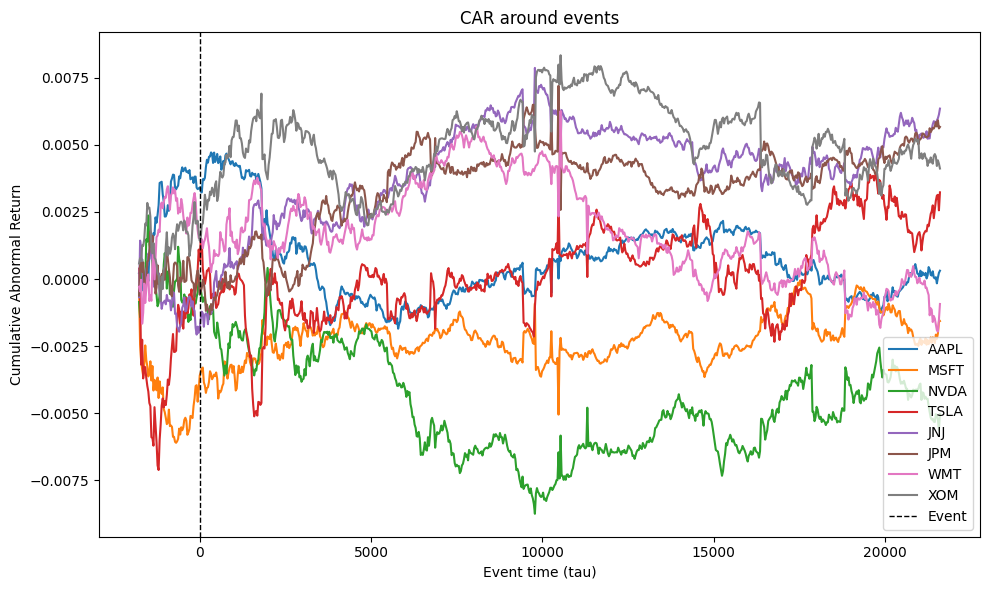

In [63]:
plt.figure(figsize=(10, 6))
for stock in stocks:
    plt.plot(avg_car['tau'], avg_car[f'{stock}_CAR'], label=stock)

plt.axvline(0, color='black', linestyle='--', linewidth=1, label='Event')
plt.xlabel('Event time (tau)')
plt.ylabel('Cumulative Abnormal Return')
plt.title('CAR around events')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
for stock in stocks:
    cleaned_data[f'{stock}_AV'] = cleaned_data[f'{stock}_volume'] - cleaned_data['SPX500/USD_volume']

In [84]:
for stock in stocks:
    cleaned_data[f'{stock}_CAV'] = (
        cleaned_data.groupby('event_id')[f'{stock}_AV'].cumsum()
    )

In [85]:
cav_cols = [f'{stock}_CAV' for stock in stocks]
avg_cav = cleaned_data.groupby('tau')[cav_cols].mean().reset_index()

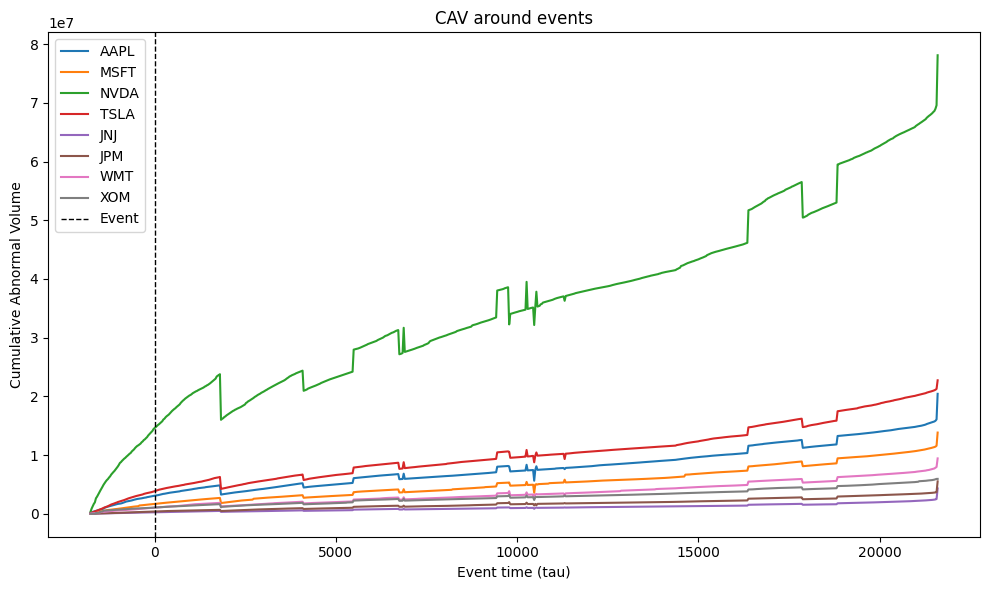

In [86]:
plt.figure(figsize=(10, 6))
for stock in stocks:
    plt.plot(avg_cav['tau'], avg_cav[f'{stock}_CAV'], label=stock)

plt.axvline(0, color='black', linestyle='--', linewidth=1, label='Event')
plt.xlabel('Event time (tau)')
plt.ylabel('Cumulative Abnormal Volume')
plt.title('CAV around events')
plt.legend()
plt.tight_layout()
plt.show()